> **Data required:** This notebook uses InSight HP3 data from Spohn et al. (2024).
> Download the Excel files from [FigShare](https://doi.org/10.6084/m9.figshare.25099754)
> and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.
>
> **Read `data-visualization.ipynb` first** to understand the raw data and the physics it reveals.

# 1D Heat Diffusion on Mars — InSight HP³ Thermal PINN

The **1D heat diffusion equation** describes how temperature propagates through a medium over time. With no fluid motion, no sources, and no sinks, heat simply conducts through the soil driven by temperature gradients:

$$\frac{\partial T}{\partial t} = \kappa \frac{\partial^2 T}{\partial x^2}$$

**Where:**
- $T(t, x)$ = temperature at depth $x$ and time $t$
- $\frac{\partial T}{\partial t}$ = how fast temperature is changing at a point
- $\frac{\partial^2 T}{\partial x^2}$ = the curvature of the temperature profile — if you are hotter than both neighbours, heat flows outward; cooler, and it flows in
- $\kappa = 3.93 \times 10^{-8}\ \text{m}^2/\text{s}$ = thermal diffusivity of Martian regolith — an extremely small number, meaning heat propagates *very slowly* through the fine-grained dust

**Physical meaning:** The Martian surface is hammered by a diurnal temperature swing of over 100 K every sol — from below 200 K at night to above 280 K at midday. That thermal pulse tries to penetrate downward through the soil, but $\kappa$ is so small that it decays rapidly with depth. By the time you reach the mole at ~9 cm, only the diurnal wave's ghost remains. This equation governs everything between the surface and the probe.

**The leap from synthetic to real:** Every previous notebook used manufactured exact solutions or idealised initial conditions. This notebook breaks that pattern entirely. There is no exact solution. The boundary conditions are **real measured data** from NASA's InSight lander. The interior supervision comes from the HP³ mole's own temperature sensors buried in Martian soil. The PINN must reconcile physics, boundary measurements, and subsurface observations simultaneously — this is the inverse-flavoured, data-driven regime that PINNs were built for.

---

## This Problem Setup

**Domain:** $x \in [0,\ 0.4\ \text{m}]$ (depth), $t \in [0,\ 88775.244\ \text{s}]$ (one Martian sol)

All inputs are normalised to $[0, 1]$ before entering the network. Temperatures are normalised over the range $[185\ \text{K},\ 300\ \text{K}]$. The effective normalised diffusivity becomes:

$$\kappa_\text{eff} = \kappa \cdot \frac{t_\text{max} - t_\text{min}}{(x_\text{max} - x_\text{min})^2}$$

---

## Three Sources of Supervision

Unlike all previous notebooks, this PINN is trained on **three distinct loss terms**:

**1. Boundary Condition Loss — 1104 points**

- *Surface* ($x = 0$): 552 real radiometer measurements from RAD Sol 511, used as Spohn et al.'s proxy for the surface temperature during the warmest sampled sol. These are unevenly spaced in local true solar time (LTST).
- *Bottom* ($x = 0.4\ \text{m}$): Fixed at $T = 225.6\ \text{K}$ for all time — the observed mean temperature at depth, where the diurnal signal has fully attenuated.

**2. Physics Residual Loss — 10,000 points**

Randomly sampled collocation points across the full $(x, t)$ domain. At each point the PINN must satisfy:

$$\frac{\partial T}{\partial t} - \kappa \frac{\partial^2 T}{\partial x^2} = 0$$

**3. Data Loss — subsurface mole measurements**

Temperature readings from TEM-A Sol 1202 at $x \approx 0.094\ \text{m}$ — the representative mole depth for the diurnal signal. These interior observations pin the network's solution inside the domain, far from any boundary, giving it direct physical evidence of what the subsurface actually looks like.

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
kappa_eff = kappa * (t_max - t_min) / ((x_max - x_min)**2)  # Effective diffusivity in normalized space


# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.
    
    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization
        
    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))
    
    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        
        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])
        
        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })
    
    return params


def network(params, x):
    """
    Forward pass through the network.
    
    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)
        
    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)
    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)
    
    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']
    
    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, kappa_eff):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]
    
    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    return du_dt - kappa_eff * d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params and kappa_eff fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, None))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, kappa_eff, t_data, x_data, u_data):

    def loss_fn(params):
        
        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)
        
        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params, 
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel(), # (10000,) not (10000, 1)
                                                kappa_eff)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)
        
        return  bc_loss + physics_loss  + data_loss * 50, (bc_loss, physics_loss, data_loss)
    
        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    
    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 80000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        kappa_eff,
        t_data, x_data, u_data
    )
    
    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)

    
    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")





Iteration 1000/80000, Loss: 0.052949
Iteration 2000/80000, Loss: 0.049817
Iteration 3000/80000, Loss: 0.049807
Iteration 4000/80000, Loss: 0.026562
Iteration 5000/80000, Loss: 0.015823
Iteration 6000/80000, Loss: 0.009453
Iteration 7000/80000, Loss: 0.007932
Iteration 8000/80000, Loss: 0.006691
Iteration 9000/80000, Loss: 0.006815
Iteration 10000/80000, Loss: 0.006156
Iteration 11000/80000, Loss: 0.005328
Iteration 12000/80000, Loss: 0.005606
Iteration 13000/80000, Loss: 0.011226
Iteration 14000/80000, Loss: 0.004684
Iteration 15000/80000, Loss: 0.005030
Iteration 16000/80000, Loss: 0.004547
Iteration 17000/80000, Loss: 0.004652
Iteration 18000/80000, Loss: 0.004466
Iteration 19000/80000, Loss: 0.004437
Iteration 20000/80000, Loss: 0.004446
Iteration 21000/80000, Loss: 0.004390
Iteration 22000/80000, Loss: 0.004338
Iteration 23000/80000, Loss: 0.004268
Iteration 24000/80000, Loss: 0.004417
Iteration 25000/80000, Loss: 0.004234
Iteration 26000/80000, Loss: 0.004185
Iteration 27000/80000

## loss Curves

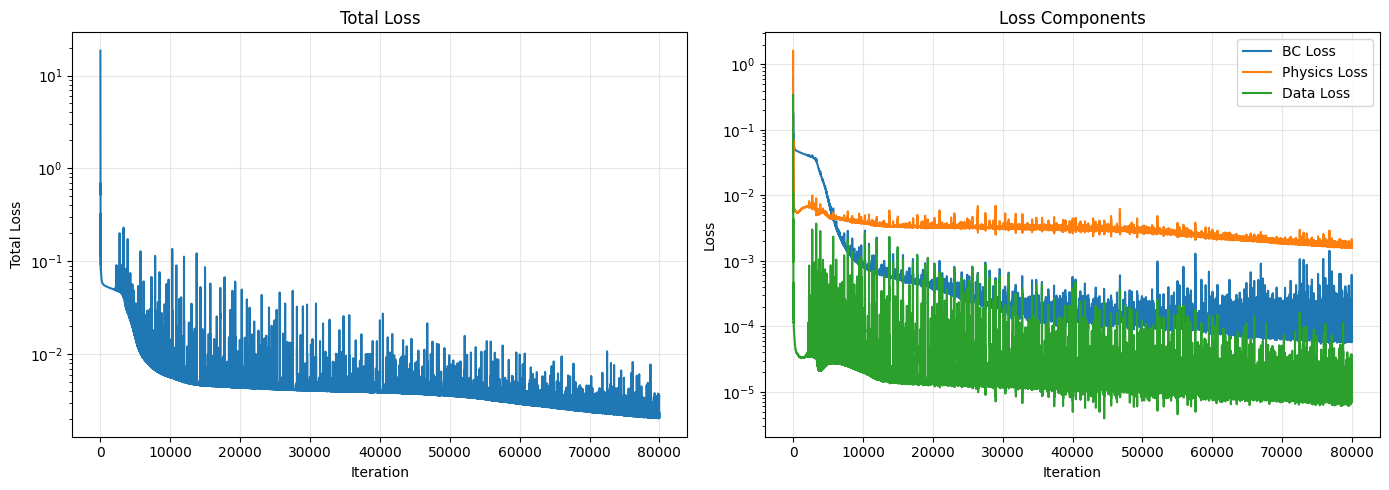

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

iterations = np.arange(1, len(losses) + 1)

# Left: total loss
ax1.semilogy(iterations, losses)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Total Loss')
ax1.set_title('Total Loss')
ax1.grid(True, alpha=0.3)

# Right: individual components
ax2.semilogy(iterations, losses_bc, label='BC Loss')
ax2.semilogy(iterations, losses_phys, label='Physics Loss')
ax2.semilogy(iterations, losses_data, label='Data Loss')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss')
ax2.set_title('Loss Components')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mars_loss_curves.png', dpi=150)
plt.show()

## Compare PINN with Data

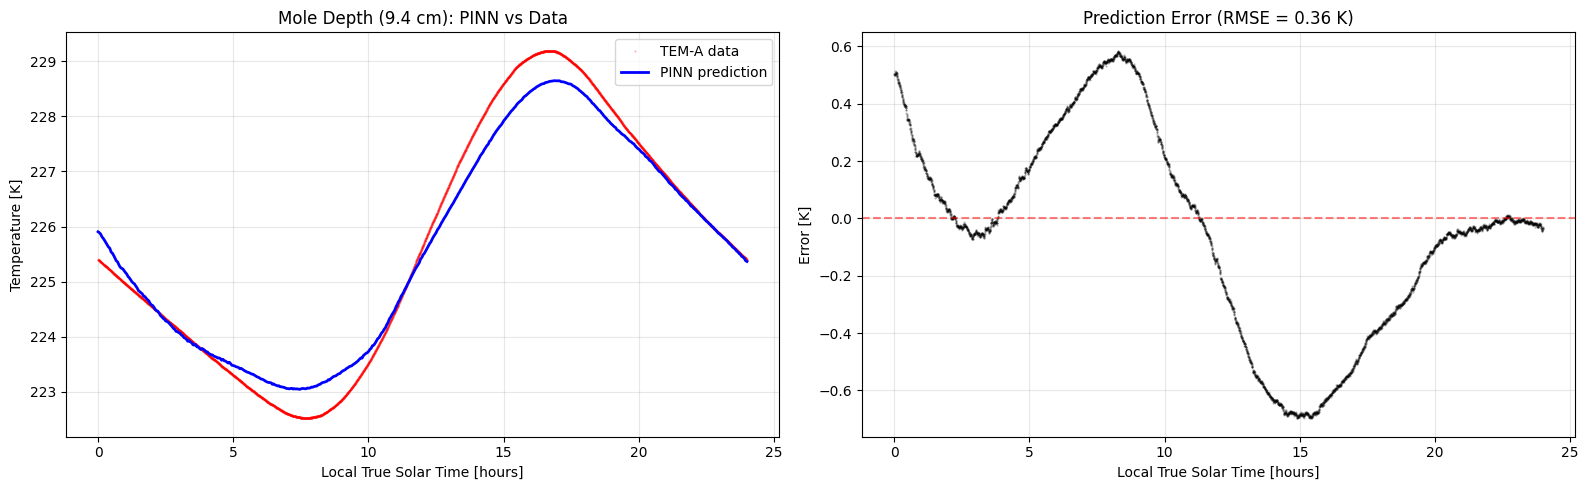

In [12]:
# ============================================================
# Plot: Network prediction vs TEM-A data at mole depth
# ============================================================

# Create a dense time array at the mole depth (normalised)
t_plot = jnp.linspace(0, 1, 500).reshape(-1, 1)  # normalised time [0,1]
x_plot = jnp.ones((500, 1)) * normalize_x(mole_depth)  # normalised mole depth

# Network prediction (normalised)
tx_plot = jnp.concatenate([t_plot, x_plot], axis=1)
u_pred_norm = network(params, tx_plot)

# Convert back to physical units
t_plot_hours = np.array(t_plot.ravel()) * 24  # back to LTST hours
u_pred_K = np.array(unnormalize_u(u_pred_norm.ravel()))  # back to Kelvin

# Also convert mole data back to hours for comparison
t_mole_hours = np.array(ltst_mole) * 24 / sol_seconds * (24/24)  
# Actually ltst_mole is already in seconds (converted earlier), so:
t_mole_hours = np.array(ltst_mole) / sol_seconds * 24  # seconds -> LTST hours
u_mole_K = np.array(temp_mole)  # already in Kelvin

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: overlay prediction and data
ax1 = axes[0]
ax1.plot(t_mole_hours, u_mole_K, 'r.', markersize=1, alpha=0.3, label='TEM-A data')
ax1.plot(t_plot_hours, u_pred_K, 'b-', linewidth=2, label='PINN prediction')
ax1.set_xlabel('Local True Solar Time [hours]')
ax1.set_ylabel('Temperature [K]')
ax1.set_title('Mole Depth (9.4 cm): PINN vs Data')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: error (prediction - data) over time
# Interpolate prediction to data time points for direct comparison
u_pred_at_data = np.interp(t_mole_hours, t_plot_hours, u_pred_K)
error = u_pred_at_data - u_mole_K

ax2 = axes[1]
ax2.plot(t_mole_hours, error, 'k.', markersize=1, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax2.set_xlabel('Local True Solar Time [hours]')
ax2.set_ylabel('Error [K]')
ax2.set_title(f'Prediction Error (RMSE = {np.sqrt(np.mean(error**2)):.2f} K)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()